# ***Link to drive***

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')
print("Current root path: ")
!pwd

Mounted at /content/gdrive
Current root path: 
/content


In [2]:
print("Switch to: ")
%cd gdrive/MyDrive/Lab/DeePMD_SiC/

Switch to: 
/content/gdrive/MyDrive/Lab/DeePMD_SiC


# ***Install DeePMD-Kit***

In [ ]:
#!nvidia-smi

In [4]:
!pip install -q deepmd-kit[gpu,lmp,ipi] dpdata

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.9/81.9 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.6/487.6 kB 37.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 108.4 MB/s eta 0:00:00


# ***Practice***

In [16]:
# import dpdata
import numpy as np
import dpdata

# load data of abacus/md format
data = dpdata.LabeledSystem('NVT_20H_300-1/output.out', fmt = 'siesta/aimd_output')
print('# the data contains %d frames' % len(data))

# random choose 40 index for validation_data
index_validation = np.random.choice(1000,size=200,replace=False)

# other indexes are training_data
index_training = list(set(range(1000))-set(index_validation))
data_training = data.sub_system(index_training)
data_validation = data.sub_system(index_validation)

# all training data put into directory:"training_data"
# data_training.to_deepmd_npy('training_data_NVT_20H_300-1')
data_training.to_deepmd_npy('training_data')

# all validation data put into directory:"validation_data"
# data_validation.to_deepmd_npy('validation_data_NVT_20H_300-1')
data_validation.to_deepmd_npy('validation_data')

print('# the training data contains %d frames' % len(data_training))
print('# the validation data contains %d frames' % len(data_validation))

# the data contains 1000 frames
# the training data contains 800 frames
# the validation data contains 200 frames


In [6]:
# import dpdata
import numpy as np
import dpdata

# load data of abacus/md format
data = dpdata.LabeledSystem('NVT_20H_300-10/output.out', fmt = 'siesta/aimd_output')
print('# the data contains %d frames' % len(data))

# random choose 40 index for validation_data
index_validation = np.random.choice(1000,size=200,replace=False)

# other indexes are training_data
index_training = list(set(range(1000))-set(index_validation))
data_training = data.sub_system(index_training)
data_validation = data.sub_system(index_validation)

# all training data put into directory:"training_data"
# data_training.to_deepmd_npy('training_data_NVT_20H_300-10')
data_training.to_deepmd_npy('training_data')

# all validation data put into directory:"validation_data"
# data_validation.to_deepmd_npy('validation_data_NVT_20H_300-10')
data_validation.to_deepmd_npy('validation_data')

print('# the training data contains %d frames' % len(data_training))
print('# the validation data contains %d frames' % len(data_validation))

# the data contains 1000 frames
# the training data contains 800 frames
# the validation data contains 200 frames


## Combine two datasets into one

In [ ]:
import numpy as np
import os

def combine_npy_files(folder1, folder2, output_folder, npy_files):
    # Create the output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)

    # Combine and save each .npy file
    for file_name in npy_files:
        data1 = np.load(os.path.join(folder1, file_name))
        data2 = np.load(os.path.join(folder2, file_name))
        combined_data = np.vstack((data1, data2))
        np.save(os.path.join(output_folder, file_name), combined_data)
        print(f'Combined {file_name} and saved to {output_folder}')

# List of .npy files to be combined
npy_files = ['virial.npy', 'force.npy', 'energy.npy', 'coord.npy', 'box.npy']

# Combine training data
combine_npy_files('training_data_NVT_20H_300-1/set.000/',
                  'training_data_NVT_20H_300-10/set.000/',
                  'training_data/set.000/',
                  npy_files)

# Combine validation data
combine_npy_files('validation_data_NVT_20H_300-1/set.000/',
                  'validation_data_NVT_20H_300-10/set.000/',
                  'validation_data/set.000/',
                  npy_files)

print("All files for both training and validation data have been combined and saved.")


Combined virial.npy and saved to training_data/set.000/virial.npy
Combined force.npy and saved to training_data/set.000/force.npy
Combined energy.npy and saved to training_data/set.000/energy.npy
Combined coord.npy and saved to training_data/set.000/coord.npy
Combined box.npy and saved to training_data/set.000/box.npy
Combined virial.npy and saved to validation_data/set.000/virial.npy
Combined force.npy and saved to validation_data/set.000/force.npy
Combined energy.npy and saved to validation_data/set.000/energy.npy
Combined coord.npy and saved to validation_data/set.000/coord.npy
Combined box.npy and saved to validation_data/set.000/box.npy
All files have been combined and saved.


In [26]:
# import dpdata
import numpy as np
import dpdata

# load data of abacus/md format
data = dpdata.LabeledSystem('NVT_20H_300-1-0.1fs/output.out', fmt = 'siesta/aimd_output')
print('# the data contains %d frames' % len(data))

# random choose 40 index for validation_data
index_validation = np.random.choice(1000,size=200,replace=False)

# other indexes are training_data
index_training = list(set(range(1000))-set(index_validation))
data_training = data.sub_system(index_training)
data_validation = data.sub_system(index_validation)

# all training data put into directory:"training_data"
data_training.to_deepmd_npy('training_data')

# all validation data put into directory:"validation_data"
data_validation.to_deepmd_npy('validation_data')

print('# the training data contains %d frames' % len(data_training))
print('# the validation data contains %d frames' % len(data_validation))

# the data contains 1000 frames
# the training data contains 800 frames
# the validation data contains 200 frames


In [27]:
# ########## Time Warning: 120 secs,C32_CPU ; 13 mins ,C2_CPU ##########
!dp train input.json

2024-09-28 16:14:47.339994: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-28 16:14:47.365886: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-28 16:14:47.365939: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-28 16:14:48.385990: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Instructions for updating:
non-resource variables are not supported in the long term
DEEPMD INFO    Calculate neighbor statistics... (add --skip-neighbor-stat to skip this step)
2024-09-28 16:14:57.716767: W external/local_tsl/tsl/framework

In [28]:
!head -n 2 lcurve.out && tail -n 2 lcurve.out

#  step      rmse_val    rmse_trn    rmse_e_val  rmse_e_trn    rmse_f_val  rmse_f_trn         lr
# If there is no available reference data, rmse_*_{val,trn} will print nan
   9800      1.88e-01    4.20e-01      1.10e-03    7.77e-03      1.84e-01    3.99e-01    4.3e-08
  10000      1.70e-01    1.82e-01      1.36e-03    1.62e-04      1.67e-01    1.79e-01    3.5e-08


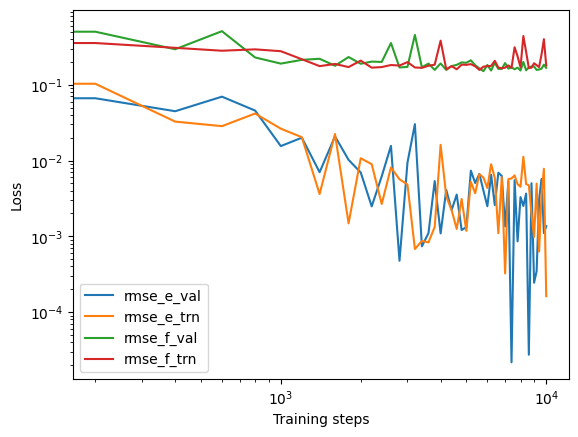

<Figure size 640x480 with 0 Axes>

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
with open("lcurve.out") as f:
    headers = f.readline().split()[1:]
lcurve = pd.DataFrame(np.loadtxt("lcurve.out"), columns =  headers    )
legends = ["rmse_e_val", "rmse_e_trn", "rmse_f_val" , "rmse_f_trn" ]
for legend in legends:
    plt.loglog(lcurve["step"], lcurve[legend], label = legend )
plt.legend()
plt.xlabel("Training steps")
plt.ylabel("Loss")
plt.show()
plt.savefig('output_loss.png')

In [30]:
## Navigate to the DeePMD-kit_Tutorial/01.train/ Directory to Train and Freeze the Model
!dp freeze -o graph.pb

2024-09-28 16:22:35.693270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-28 16:22:35.731674: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-28 16:22:35.731731: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-28 16:22:36.753301: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Instructions for updating:
non-resource variables are not supported in the long term
2024-09-28 16:22:39.635788: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROW

In [31]:
## Navigate to the DeePMD-kit_Tutorial/01.train/ Directory to Compress the Model
!dp compress -i graph.pb -o compress.pb

2024-09-28 16:22:42.412776: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-28 16:22:42.437898: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-28 16:22:42.437951: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-28 16:22:43.464848: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Instructions for updating:
non-resource variables are not supported in the long term
2024-09-28 16:22:45.574463: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROW

In [32]:
!dp test -m graph.pb -s validation_data

2024-09-28 16:23:00.419047: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-28 16:23:00.460346: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-28 16:23:00.460404: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-28 16:23:01.954566: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
Instructions for updating:
non-resource variables are not supported in the long term
DEEPMD INFO    # ---------------output of dp test--------------- 
DEEPMD INFO    # testing system : validation_data
2024-09-28 16:23:16.768644: W external/

In [33]:
import dpdata

training_systems = dpdata.LabeledSystem("training_data", fmt = "deepmd/npy")
predict = training_systems.predict("graph.pb")

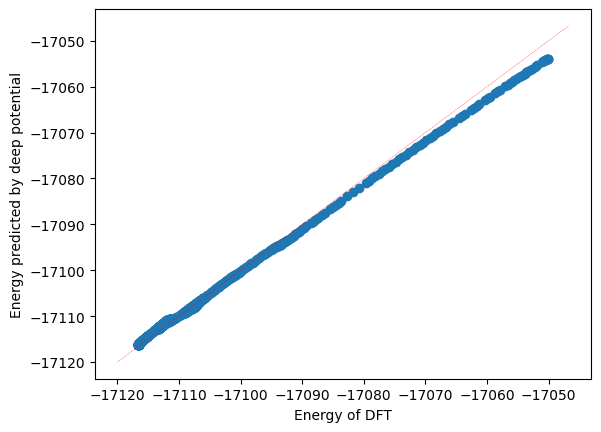

In [34]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(training_systems["energies"], predict["energies"])

x_range = np.linspace(plt.xlim()[0], plt.xlim()[1])

plt.plot(x_range, x_range, "r--", linewidth = 0.25)
plt.xlabel("Energy of DFT")
plt.ylabel("Energy predicted by deep potential")
plt.plot()
plt.savefig('output_predict.png')

In [ ]:
!lmp -i in.lammps

2024-09-18 14:05:32.493441: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-09-18 14:05:32.519262: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-09-18 14:05:32.519382: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-09-18 14:05:32.534984: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-09-18 14:05:33.548497: W tensorflow/com